In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib, warnings
warnings.filterwarnings('ignore')

from neuralprophet import NeuralProphet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [18]:
PRICE_DATA_PATH    = (
    'CS-IDX30 version 3/'
    'pricehistory data/Finance/BBCA.JK_dataprice.xlsx'
)
RF_SIGNAL_PATH     = 'rf_idx30_predictions.csv'

TEST_SIZE          = 120      # last N trading days for final evaluation
ALPHA_RANGE        = np.arange(0.0, 1.05, 0.05)   # weights to search over

# NeuralProphet hyperparameters (same as NeuralProphetWilbert.ipynb)
NP_PARAMS = dict(
    n_lags             = 1,
    n_forecasts        = 1,
    learning_rate      = 0.01,
    seasonality_mode   = 'additive',
    epochs             = 100,
    yearly_seasonality = True,
    weekly_seasonality = True,
    daily_seasonality  = False,
    quantiles          = [0.05, 0.95],
)


In [19]:
def load_price_data(path):
    df = pd.read_excel(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df = df.rename(columns={'Date': 'ds', 'Close': 'y'})[['ds', 'y']]
    print(f"[Price]  {df['ds'].min().date()} to {df['ds'].max().date()}  ({len(df)} rows)")
    return df

df_price = load_price_data(PRICE_DATA_PATH)


[Price]  2017-07-31 to 2022-07-29  (1256 rows)


In [20]:
import os

NP_FORECAST_PATH = 'np_baseline_forecast.csv'

if os.path.exists(NP_FORECAST_PATH):
    print(f"[NP] Loading pre-trained forecast from {NP_FORECAST_PATH} ...")
    forecast_np = pd.read_csv(NP_FORECAST_PATH, parse_dates=['ds'])
    print(f"NeuralProphet forecast loaded — {len(forecast_np)} rows "
          f"({forecast_np['ds'].min().date()} to {forecast_np['ds'].max().date()})")
else:
    print("[NP] CSV not found — training NeuralProphet baseline from scratch ...")
    model_np = NeuralProphet(**NP_PARAMS)
    model_np.add_seasonality(name='quarterly', period=91.31, fourier_order=5)
    model_np.fit(df_price, freq='D')
    future      = model_np.make_future_dataframe(df_price, periods=0, n_historic_predictions=True)
    forecast_np = model_np.predict(future).iloc[:len(df_price)].copy()
    forecast_np = forecast_np[['ds', 'yhat1']]
    print(f"NeuralProphet forecast ready — {len(forecast_np)} rows")

[NP] Loading pre-trained forecast from np_baseline_forecast.csv ...
NeuralProphet forecast loaded — 565 rows (2020-03-31 to 2021-10-16)


In [21]:
def load_rf_signal(path, df_price):
    """
    Load quarterly RF signal and forward-fill onto every trading day.
    Each day inherits the RF signal from the most recently completed quarter.
    """
    rf = pd.read_csv(path, parse_dates=['ds'])
    rf = rf.sort_values('ds').reset_index(drop=True)
    print(f"[RF Signal]  {len(rf)} quarters")
    print(rf[['ds', 'quarter_label', 'rf_signal']].to_string(index=False))

    # Merge onto full calendar range then forward-fill
    date_range = pd.DataFrame({'ds': pd.date_range(df_price['ds'].min(),
                                                     df_price['ds'].max(), freq='D')})
    daily = date_range.merge(rf[['ds', 'rf_signal']], on='ds', how='left')
    daily['rf_signal'] = daily['rf_signal'].ffill()

    # Join to actual trading days only
    df_daily_rf = df_price[['ds']].merge(daily, on='ds', how='left')
    n_filled = df_daily_rf['rf_signal'].notna().sum()
    print(f"\n[Daily RF]  {n_filled} trading days have an RF signal "
          f"({df_daily_rf['rf_signal'].isna().sum()} days without signal — pre-RF period)")
    return df_daily_rf

df_rf_daily = load_rf_signal(RF_SIGNAL_PATH, df_price)


[RF Signal]  8 quarters
        ds quarter_label  rf_signal
2020-03-31       2020-Q1   0.000984
2020-06-30       2020-Q2  -0.000593
2020-09-30       2020-Q3   0.002822
2020-12-31       2020-Q4  -0.000291
2021-03-31       2021-Q1   0.000602
2021-06-30       2021-Q2   0.002077
2021-09-30       2021-Q3   0.001055
2021-12-31       2021-Q4   0.000863

[Daily RF]  565 trading days have an RF signal (691 days without signal — pre-RF period)


In [22]:
def build_hybrid(df_price, forecast_np, df_rf_daily, alpha):
    df = df_price[['ds', 'y']].copy()

    # Merge on ds — safe when forecast and price have different row counts
    df = df.merge(forecast_np[['ds', 'yhat1']].rename(columns={'yhat1': 'np_pred'}),
                  on='ds', how='left')
    df = df.merge(df_rf_daily[['ds', 'rf_signal']], on='ds', how='left')

    df = df.dropna(subset=['rf_signal', 'np_pred']).reset_index(drop=True)

    df['np_return'] = np.log(df['np_pred'] / df['np_pred'].shift(1))
    df = df.dropna(subset=['np_return']).reset_index(drop=True)

    df['hybrid_return'] = (1 - alpha) * df['np_return'] + alpha * df['rf_signal']

    start_price = df['y'].iloc[0]
    df['hybrid_pred'] = start_price * np.exp(df['hybrid_return'].cumsum())

    df = df.dropna(subset=['hybrid_pred', 'np_pred', 'y']).reset_index(drop=True)
    return df

df_work    = build_hybrid(df_price, forecast_np, df_rf_daily, alpha=0.0)
val_cut    = int(len(df_work) * 0.8)
print(f"Working period : {len(df_work)} days")
print(f"Validation     : {val_cut} days")
print(f"Test           : {len(df_work) - val_cut} days")

best_alpha, best_mae = 0.0, float('inf')
for alpha in ALPHA_RANGE:
    df_tmp     = build_hybrid(df_price, forecast_np, df_rf_daily, alpha)
    df_tmp_val = df_tmp.iloc[:val_cut]
    mae = mean_absolute_error(df_tmp_val['y'].values, df_tmp_val['hybrid_pred'].values)
    if mae < best_mae:
        best_mae, best_alpha = mae, alpha

print(f"\nBest alpha (validation) : {best_alpha:.2f}")
print(f"Best validation MAE     : {best_mae:,.2f}")

df_hybrid = build_hybrid(df_price, forecast_np, df_rf_daily, best_alpha)

Working period : 372 days
Validation     : 297 days
Test           : 75 days

Best alpha (validation) : 0.00
Best validation MAE     : 154.13


In [23]:
def evaluate(y_true, y_pred, label):
    mae     = mean_absolute_error(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mean_p  = y_true.mean()
    dir_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
    print(f"\n  {label}")
    print(f"  MAE        : {mae:>10,.2f}  ({mae/mean_p*100:.2f}%)")
    print(f"  RMSE       : {rmse:>10,.2f}  ({rmse/mean_p*100:.2f}%)")
    print(f"  Dir. Acc   : {dir_acc:.1f}%")
    return dict(label=label, MAE=mae, RMSE=rmse,
                MAE_pct=mae/mean_p*100, RMSE_pct=rmse/mean_p*100, Dir_Acc=dir_acc)

# Evaluate on the test portion of the RF overlap period
df_eval = df_hybrid.iloc[val_cut:].reset_index(drop=True)

print("=" * 55)
print("  EVALUATION — RF overlap test period")
print("=" * 55)

m_np = evaluate(df_eval['y'].values,
                df_eval['np_pred'].values,    'NeuralProphet Baseline')
m_hy = evaluate(df_eval['y'].values,
                df_eval['hybrid_pred'].values, f'Hybrid (alpha={best_alpha:.2f})')


  EVALUATION — RF overlap test period

  NeuralProphet Baseline
  MAE        :      63.94  (1.01%)
  RMSE       :      92.72  (1.46%)
  Dir. Acc   : 35.1%

  Hybrid (alpha=0.00)
  MAE        :     181.67  (2.86%)
  RMSE       :     202.42  (3.19%)
  Dir. Acc   : 35.1%


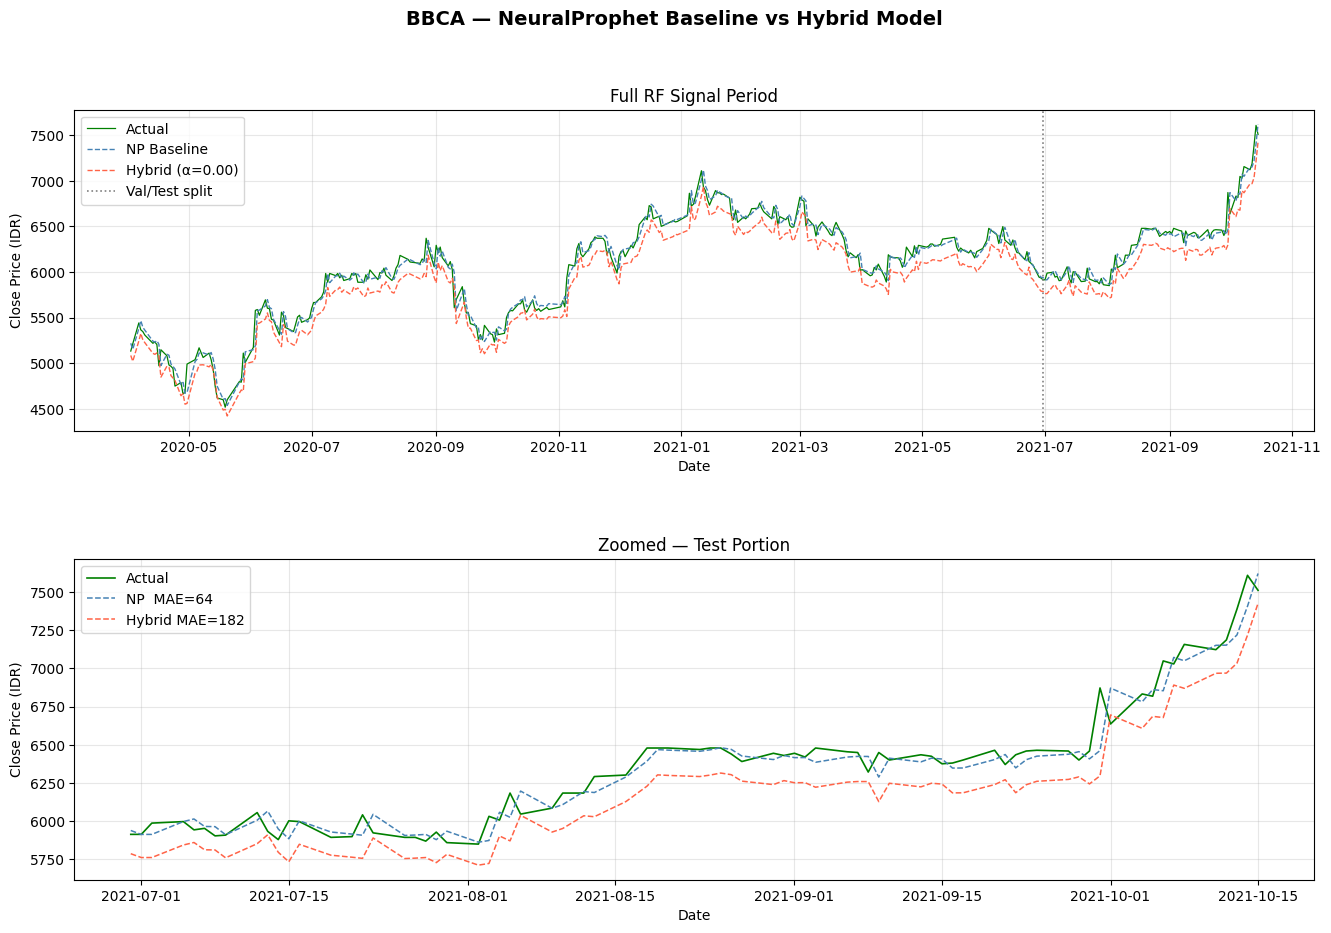

[Saved] hybrid_comparison.png


In [24]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('BBCA — NeuralProphet Baseline vs Hybrid Model',
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Full RF period ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_hybrid['ds'], df_hybrid['y'],           color='green',     label='Actual',     linewidth=0.9)
ax1.plot(df_hybrid['ds'], df_hybrid['np_pred'],     color='steelblue', label='NP Baseline', linewidth=1.0, linestyle='--')
ax1.plot(df_hybrid['ds'], df_hybrid['hybrid_pred'], color='tomato',    label=f'Hybrid (α={best_alpha:.2f})', linewidth=1.0, linestyle='--')
ax1.axvline(df_hybrid['ds'].iloc[val_cut], color='grey', linestyle=':', linewidth=1.2, label='Val/Test split')
ax1.set_title('Full RF Signal Period')
ax1.set_xlabel('Date'); ax1.set_ylabel('Close Price (IDR)')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── Zoomed test window ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(df_eval['ds'], df_eval['y'],            color='green',     label='Actual',      linewidth=1.2)
ax2.plot(df_eval['ds'], df_eval['np_pred'],      color='steelblue', label=f"NP  MAE={m_np['MAE']:,.0f}", linewidth=1.1, linestyle='--')
ax2.plot(df_eval['ds'], df_eval['hybrid_pred'],  color='tomato',    label=f"Hybrid MAE={m_hy['MAE']:,.0f}", linewidth=1.1, linestyle='--')
ax2.set_title('Zoomed — Test Portion')
ax2.set_xlabel('Date'); ax2.set_ylabel('Close Price (IDR)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.savefig('hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] hybrid_comparison.png')


In [25]:
improvement_mae  = (m_np['MAE']  - m_hy['MAE'])  / m_np['MAE']  * 100
improvement_rmse = (m_np['RMSE'] - m_hy['RMSE']) / m_np['RMSE'] * 100

print("\n" + "=" * 60)
print("  HYBRID MODEL SUMMARY")
print("=" * 60)
print(f"  Best alpha (NP/RF blend weight) : {best_alpha:.2f}")
print(f"  {'Metric':<30} {'NP Baseline':>12} {'Hybrid':>12}")
print(f"  {'-'*54}")
print(f"  {'MAE (IDR)':<30} {m_np['MAE']:>12,.2f} {m_hy['MAE']:>12,.2f}")
print(f"  {'MAE (%)':<30} {m_np['MAE_pct']:>11.2f}% {m_hy['MAE_pct']:>11.2f}%")
print(f"  {'RMSE (IDR)':<30} {m_np['RMSE']:>12,.2f} {m_hy['RMSE']:>12,.2f}")
print(f"  {'RMSE (%)':<30} {m_np['RMSE_pct']:>11.2f}% {m_hy['RMSE_pct']:>11.2f}%")
print(f"  {'Directional Accuracy':<30} {m_np['Dir_Acc']:>11.1f}% {m_hy['Dir_Acc']:>11.1f}%")
print(f"  {'-'*54}")
print(f"  MAE  improvement : {improvement_mae:+.2f}%")
print(f"  RMSE improvement : {improvement_rmse:+.2f}%")
print("=" * 60)



  HYBRID MODEL SUMMARY
  Best alpha (NP/RF blend weight) : 0.00
  Metric                          NP Baseline       Hybrid
  ------------------------------------------------------
  MAE (IDR)                             63.94       181.67
  MAE (%)                               1.01%        2.86%
  RMSE (IDR)                            92.72       202.42
  RMSE (%)                              1.46%        3.19%
  Directional Accuracy                  35.1%        35.1%
  ------------------------------------------------------
  MAE  improvement : -184.11%
  RMSE improvement : -118.31%


Quarter  N_days  NP_DirAcc_%  Hybrid_DirAcc_%  Delta_%
 2020Q2      57         57.1             57.1      0.0
 2020Q3      62         34.4             34.4      0.0
 2020Q4      59         46.6             46.6      0.0
 2021Q1      61         55.0             55.0      0.0
 2021Q2      59         56.9             56.9      0.0
 2021Q3      63         37.1             37.1      0.0
 2021Q4      11         30.0             30.0      0.0


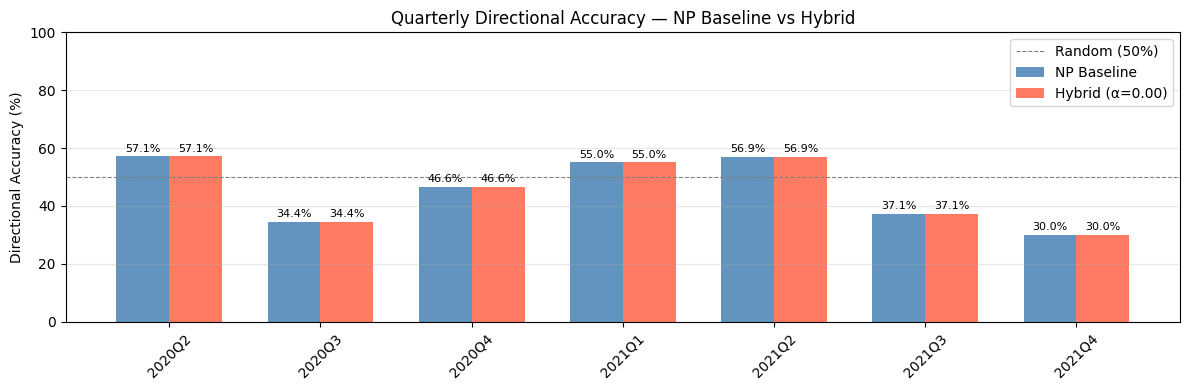

[Saved] quarterly_dir_acc.png


In [26]:
df_hybrid['quarter'] = df_hybrid['ds'].dt.to_period('Q')

rows = []
for q, grp in df_hybrid.groupby('quarter'):
    if len(grp) < 2:
        continue
    actual_dir = np.sign(np.diff(grp['y'].values))
    np_dir     = np.sign(np.diff(grp['np_pred'].values))
    hy_dir     = np.sign(np.diff(grp['hybrid_pred'].values))
    rows.append({
        'Quarter'       : str(q),
        'N_days'        : len(grp),
        'NP_DirAcc_%'   : round(np.mean(actual_dir == np_dir)  * 100, 1),
        'Hybrid_DirAcc_%': round(np.mean(actual_dir == hy_dir) * 100, 1),
    })

df_qacc = pd.DataFrame(rows)
df_qacc['Delta_%'] = df_qacc['Hybrid_DirAcc_%'] - df_qacc['NP_DirAcc_%']
print(df_qacc.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(df_qacc))
w = 0.35
b1 = ax.bar(x - w/2, df_qacc['NP_DirAcc_%'],      w, label='NP Baseline', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, df_qacc['Hybrid_DirAcc_%'],   w, label=f'Hybrid (α={best_alpha:.2f})', color='tomato', alpha=0.85)
ax.bar_label(b1, fmt='%.1f%%', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.1f%%', padding=2, fontsize=8)
ax.axhline(50, linestyle='--', color='grey', linewidth=0.8, label='Random (50%)')
ax.set_xticks(x)
ax.set_xticklabels(df_qacc['Quarter'], rotation=45)
ax.set_ylabel('Directional Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Quarterly Directional Accuracy — NP Baseline vs Hybrid')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('quarterly_dir_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] quarterly_dir_acc.png')